# 📉 Customer Churn Prediction System
**Author:** Sheran Asgar  
**Tech Stack:** Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn  
**Objective:** Predict whether a customer will churn (leave) a telecom company based on usage patterns, contract type, and service features.

---

## 📦 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 2. Load Dataset

In [2]:
# Generating realistic Telecom Customer Churn dataset
np.random.seed(42)
n = 2000

# Customer demographics
gender           = np.random.choice(['Male', 'Female'], n)
senior_citizen   = np.random.choice([0, 1], n, p=[0.84, 0.16])
partner          = np.random.choice(['Yes', 'No'], n, p=[0.48, 0.52])
dependents       = np.random.choice(['Yes', 'No'], n, p=[0.30, 0.70])
tenure           = np.random.randint(1, 72, n)  # months

# Services
phone_service    = np.random.choice(['Yes', 'No'], n, p=[0.90, 0.10])
internet_service = np.random.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.34, 0.44, 0.22])
online_security  = np.random.choice(['Yes', 'No'], n, p=[0.29, 0.71])
tech_support     = np.random.choice(['Yes', 'No'], n, p=[0.29, 0.71])
streaming_tv     = np.random.choice(['Yes', 'No'], n, p=[0.38, 0.62])

# Contract & Billing
contract         = np.random.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.55, 0.24, 0.21])
paperless_billing= np.random.choice(['Yes', 'No'], n, p=[0.59, 0.41])
payment_method   = np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n)
monthly_charges  = np.round(np.random.uniform(18, 120, n), 2)
total_charges    = np.round(monthly_charges * tenure + np.random.normal(0, 50, n), 2).clip(0)

# Churn probability based on realistic factors
churn_prob = (
    0.05
    + 0.25 * (contract == 'Month-to-month').astype(float)
    - 0.15 * (contract == 'Two year').astype(float)
    + 0.20 * (internet_service == 'Fiber optic').astype(float)
    - 0.10 * (online_security == 'Yes').astype(float)
    - 0.10 * (tech_support == 'Yes').astype(float)
    + 0.10 * (paperless_billing == 'Yes').astype(float)
    + 0.15 * (payment_method == 'Electronic check').astype(float)
    - 0.003 * tenure
    + 0.001 * monthly_charges
    + 0.08 * senior_citizen
).clip(0.05, 0.90)

churn = (np.random.random(n) < churn_prob).astype(int)

df = pd.DataFrame({
    'Gender': gender,
    'SeniorCitizen': senior_citizen,
    'Partner': partner,
    'Dependents': dependents,
    'Tenure': tenure,
    'PhoneService': phone_service,
    'InternetService': internet_service,
    'OnlineSecurity': online_security,
    'TechSupport': tech_support,
    'StreamingTV': streaming_tv,
    'Contract': contract,
    'PaperlessBilling': paperless_billing,
    'PaymentMethod': payment_method,
    'MonthlyCharges': monthly_charges,
    'TotalCharges': total_charges,
    'Churn': churn
})

df.to_csv('churn_data.csv', index=False)
print(f'✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Churn Rate: {df["Churn"].mean()*100:.1f}%')
df.head(10)

✅ Dataset created: 2000 rows × 16 columns
Churn Rate: 28.3%


,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,No,57,Yes,Fiber optic,Yes,Yes,Yes,One year,Yes,Electronic check,102.39,5761.56,0
1,Female,0,No,No,27,Yes,DSL,No,No,No,One year,No,Electronic check,97.00,2630.10,1
2,Male,1,Yes,No,5,Yes,No,Yes,No,Yes,Two year,Yes,Electronic check,86.27,390.42,0
3,Male,0,No,No,71,Yes,No,No,No,Yes,Two year,Yes,Electronic check,95.52,6834.61,0
4,Male,0,No,No,57,Yes,Fiber optic,Yes,No,No,One year,No,Electronic check,117.90,6708.87,0
5,Female,0,No,Yes,15,Yes,DSL,No,No,No,Two year,No,Bank transfer,61.97,840.92,0
6,Male,0,No,No,30,Yes,DSL,Yes,No,Yes,Month-to-month,Yes,Mailed check,24.86,771.23,1
7,Male,1,Yes,No,20,Yes,Fiber optic,No,No,No,Month-to-month,No,Electronic check,65.01,1310.64,0
8,Male,0,No,Yes,37,Yes,DSL,No,No,No,Two year,No,Bank transfer,22.74,826.39,0
9,Female,0,Yes,No,3,No,Fiber optic,No,No,No,Month-to-month,Yes,Electronic check,48.01,92.09,1


## 🔍 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'\nMissing Values:\n{df.isnull().sum()}')
print(f'\nChurn Distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {df["Churn"].mean()*100:.2f}%')

=== Dataset Info ===
Shape: (2000, 16)

Missing Values:
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
InternetService     0
OnlineSecurity      0
TechSupport         0
StreamingTV         0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn Distribution:
Churn
0    1434
1     566
Name: count, dtype: int64

Churn Rate: 28.30%


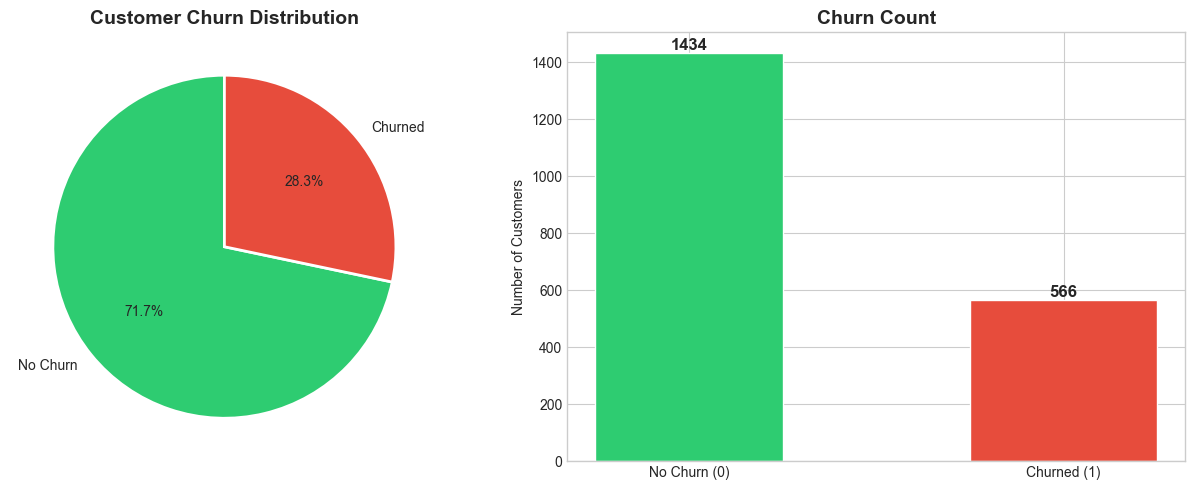

📊 Churn distribution plotted


In [4]:
# --- Churn Distribution Pie + Count ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts.values, labels=['No Churn', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

bars = axes[1].bar(['No Churn (0)', 'Churned (1)'], churn_counts.values,
                   color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Churn distribution plotted')

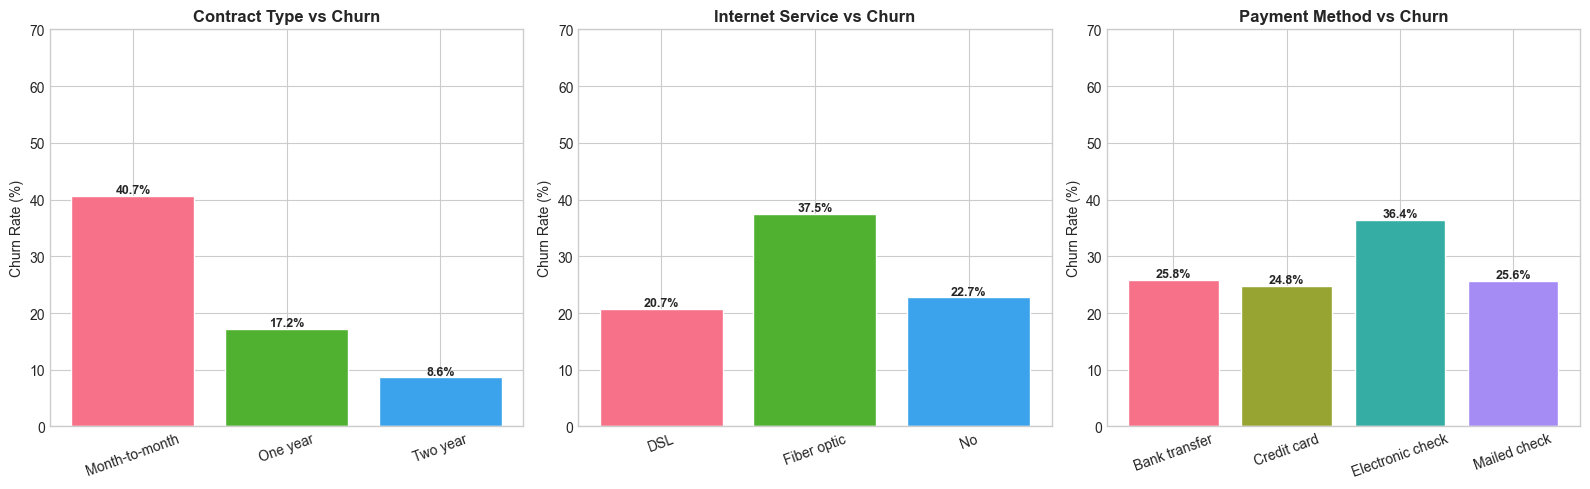

In [5]:
# --- Contract, Internet Service, Payment Method vs Churn ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cats = ['Contract', 'InternetService', 'PaymentMethod']
titles = ['Contract Type vs Churn', 'Internet Service vs Churn', 'Payment Method vs Churn']

for ax, col, title in zip(axes, cats, titles):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=sns.color_palette('husl', len(churn_rate)), edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 70)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_categorical_churn.png', dpi=150, bbox_inches='tight')
plt.show()

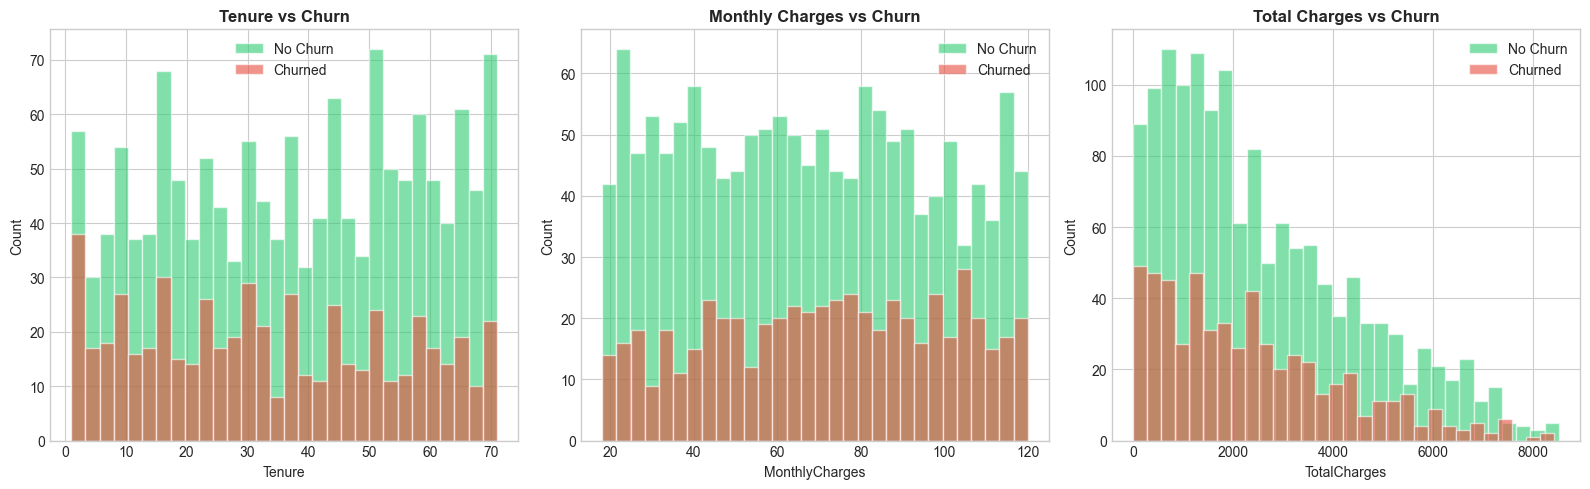

In [6]:
# --- Tenure, Monthly Charges, Total Charges vs Churn ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
titles   = ['Tenure vs Churn', 'Monthly Charges vs Churn', 'Total Charges vs Churn']

for ax, col, title in zip(axes, num_cols, titles):
    churned     = df[df['Churn'] == 1][col]
    not_churned = df[df['Churn'] == 0][col]
    ax.hist(not_churned, bins=30, alpha=0.6, color='#2ecc71', label='No Churn', edgecolor='white')
    ax.hist(churned,     bins=30, alpha=0.6, color='#e74c3c', label='Churned',  edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('plot_numerical_churn.png', dpi=150, bbox_inches='tight')
plt.show()

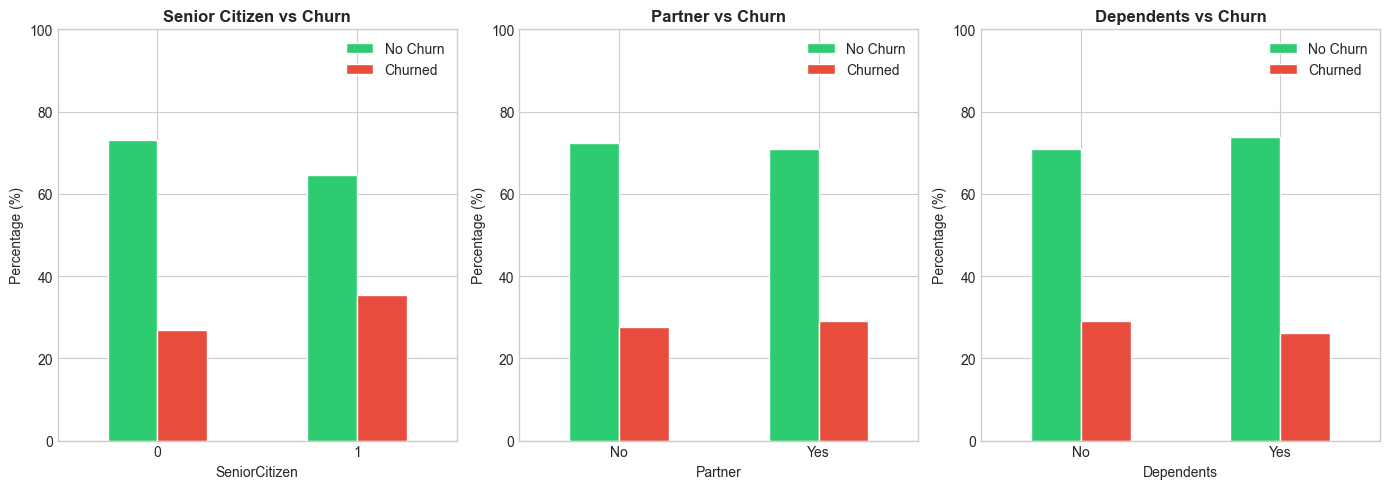

In [7]:
# --- Senior Citizen, Partner, Dependents vs Churn ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

demo_cols  = ['SeniorCitizen', 'Partner', 'Dependents']
demo_titles = ['Senior Citizen vs Churn', 'Partner vs Churn', 'Dependents vs Churn']

for ax, col, title in zip(axes, demo_cols, demo_titles):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', rot=0)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.legend(['No Churn', 'Churned'], loc='upper right')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('plot_demographics_churn.png', dpi=150, bbox_inches='tight')
plt.show()

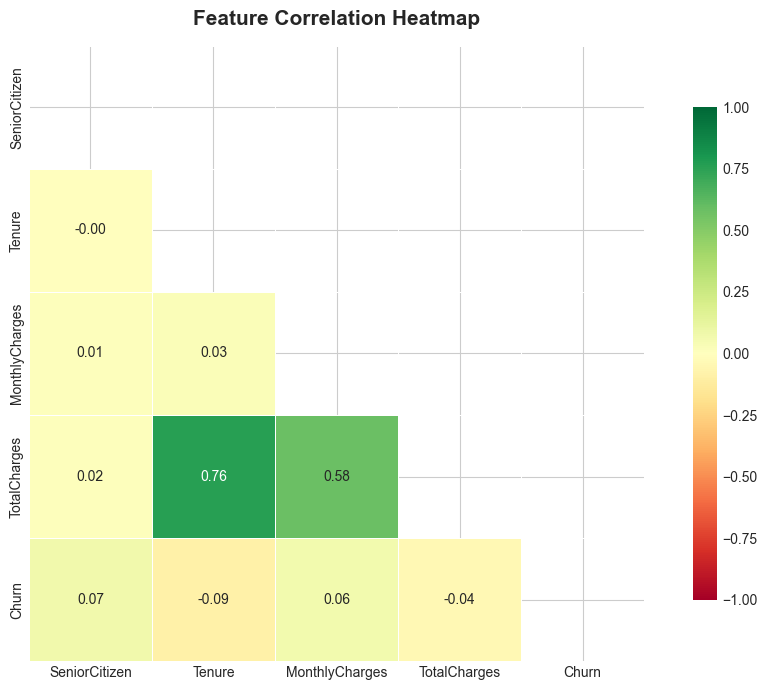

In [8]:
# --- Correlation Heatmap ---
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 🛠️ 4. Data Preprocessing

In [9]:
df_model = df.copy()

# Label encode all categorical columns
le = LabelEncoder()
cat_cols = ['Gender', 'Partner', 'Dependents', 'PhoneService',
            'InternetService', 'OnlineSecurity', 'TechSupport',
            'StreamingTV', 'Contract', 'PaperlessBilling', 'PaymentMethod']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features and Target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print(f'✅ Features: {X.shape[1]} columns')
print(f'✅ Samples:  {X.shape[0]} rows')
print(f'✅ Churn Rate: {y.mean()*100:.1f}%')
print(f'\nFeature columns: {list(X.columns)}')

✅ Features: 15 columns
✅ Samples:  2000 rows
✅ Churn Rate: 28.3%

Feature columns: ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'InternetService', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [10]:
# Train-Test Split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Train set: {X_train.shape[0]} samples')
print(f'✅ Test set:  {X_test.shape[0]} samples')
print(f'✅ Stratified split — Churn in train: {y_train.mean()*100:.1f}%')
print(f'✅ Stratified split — Churn in test:  {y_test.mean()*100:.1f}%')

✅ Train set: 1600 samples
✅ Test set:  400 samples
✅ Stratified split — Churn in train: 28.3%
✅ Stratified split — Churn in test:  28.2%


## 🤖 5. Model Training — 3 Classifiers

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
}

results = {}

print(f'{"Model":<25} | {"Accuracy":>9} | {"Precision":>9} | {"Recall":>9} | {"F1":>9} | {"ROC-AUC":>9}')
print('-' * 80)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_pred_prob)
    cm   = confusion_matrix(y_test, y_pred)
    
    cv   = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'ROC_AUC': auc, 'CM': cm,
        'y_pred': y_pred, 'y_pred_prob': y_pred_prob,
        'CV_Mean': cv.mean(), 'CV_Std': cv.std()
    }
    print(f'{name:<25} | {acc:>9.4f} | {prec:>9.4f} | {rec:>9.4f} | {f1:>9.4f} | {auc:>9.4f}')

Model                     |  Accuracy | Precision |    Recall |        F1 |   ROC-AUC
--------------------------------------------------------------------------------
Logistic Regression       |    0.7425 |    0.6087 |    0.2478 |    0.3522 |    0.7365
Decision Tree             |    0.7125 |    0.4821 |    0.2389 |    0.3195 |    0.7046
Random Forest             |    0.7425 |    0.6923 |    0.1593 |    0.2590 |    0.7381


## 📊 6. Confusion Matrix — All 3 Models

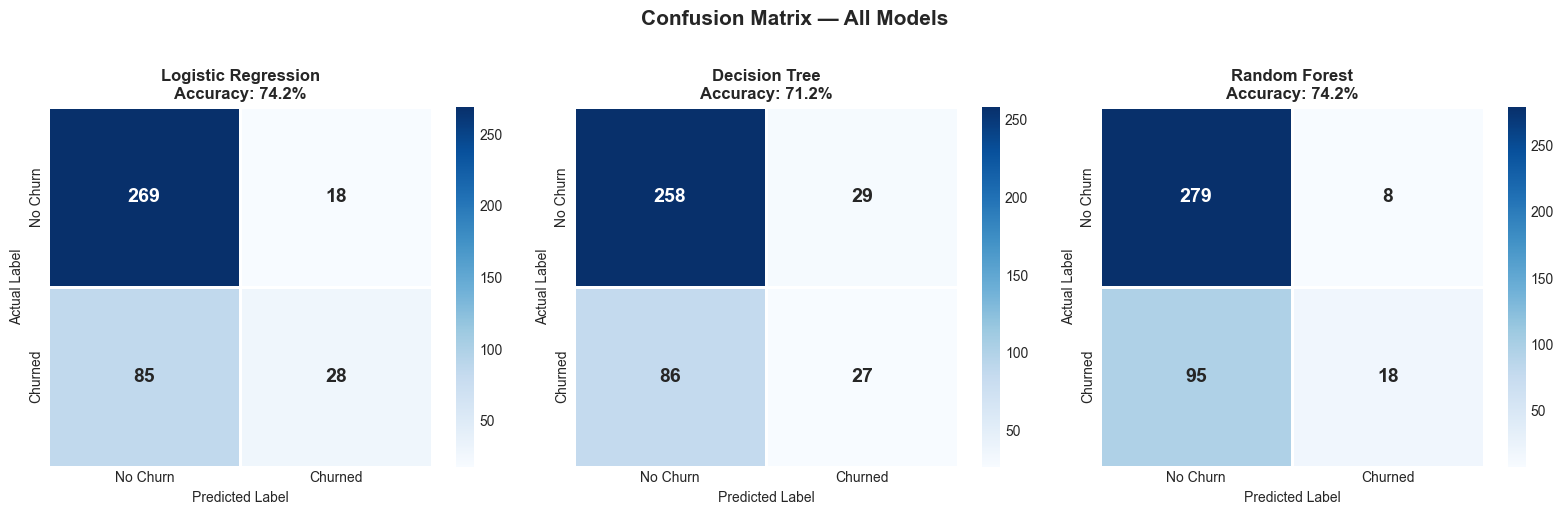

✅ Confusion matrices plotted


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = res['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churned'],
                yticklabels=['No Churn', 'Churned'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}\nAccuracy: {res["Accuracy"]*100:.1f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.suptitle('Confusion Matrix — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices plotted')

## 📈 7. Model Accuracy Comparison

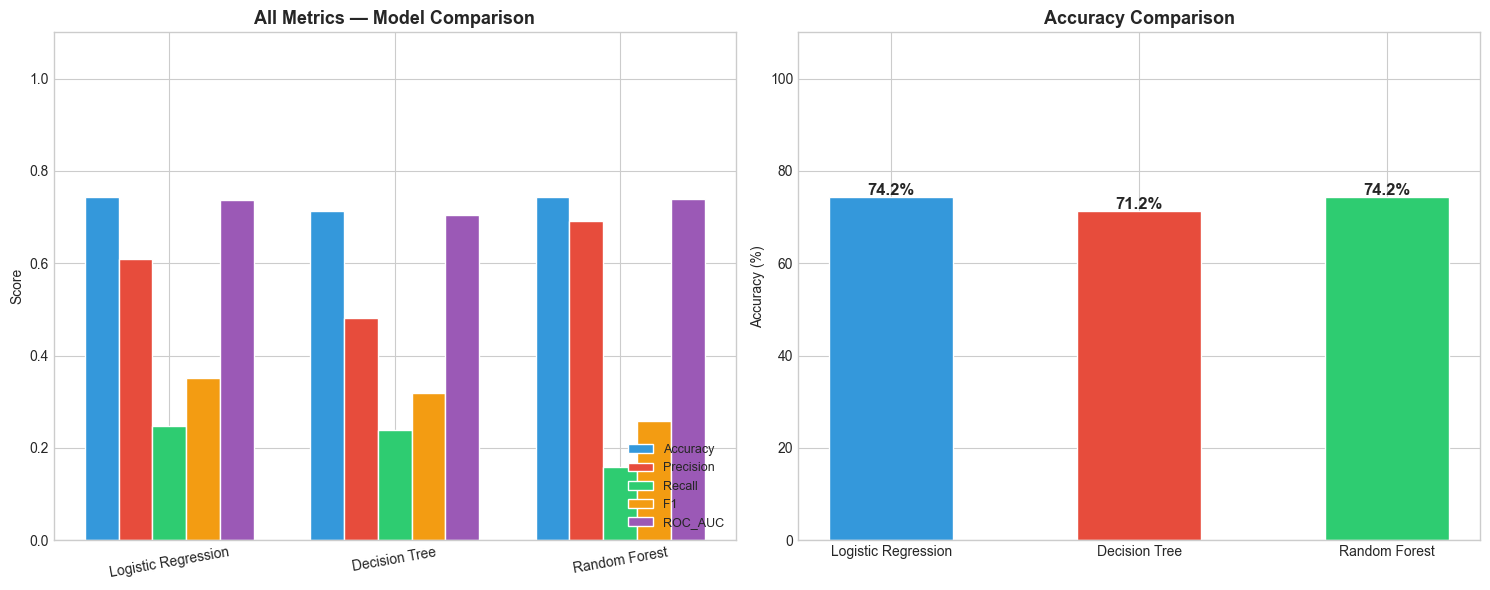

In [13]:
# --- Accuracy Comparison Bar Chart ---
model_names = list(results.keys())
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
colors_bar  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grouped bar chart
x    = np.arange(len(model_names))
width = 0.15

for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    vals = [results[m][metric] for m in model_names]
    axes[0].bar(x + i*width, vals, width, label=metric, color=color, edgecolor='white')

axes[0].set_title('All Metrics — Model Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right', fontsize=9)

# Accuracy only — clean comparison
acc_vals = [results[m]['Accuracy']*100 for m in model_names]
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[1].bar(model_names, acc_vals, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
for bar, val in zip(bars, acc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

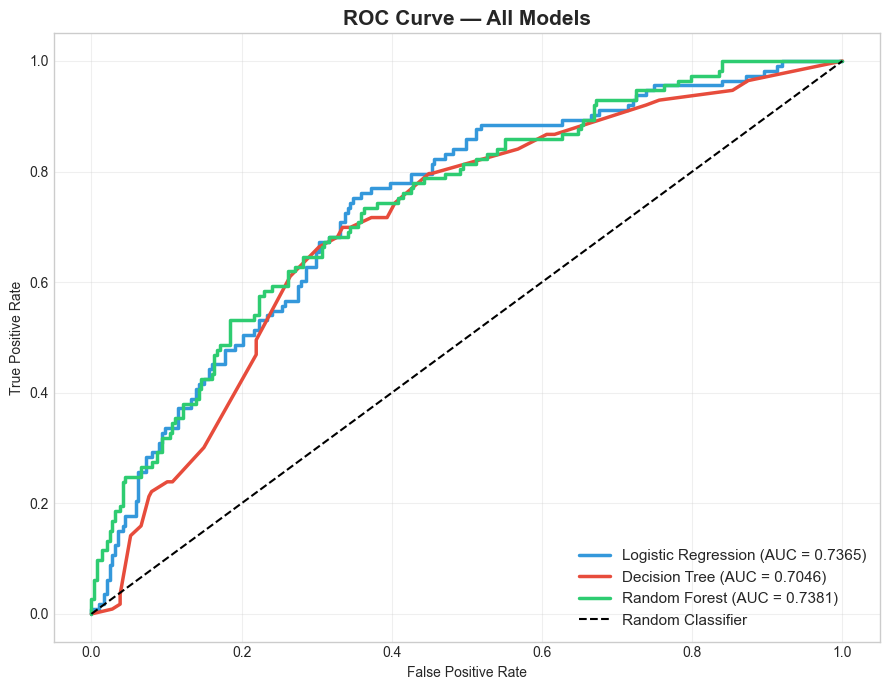

✅ ROC curves plotted


In [14]:
# --- ROC Curve --- 
plt.figure(figsize=(9, 7))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{name} (AUC = {res["ROC_AUC"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.title('ROC Curve — All Models', fontsize=15, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curves plotted')

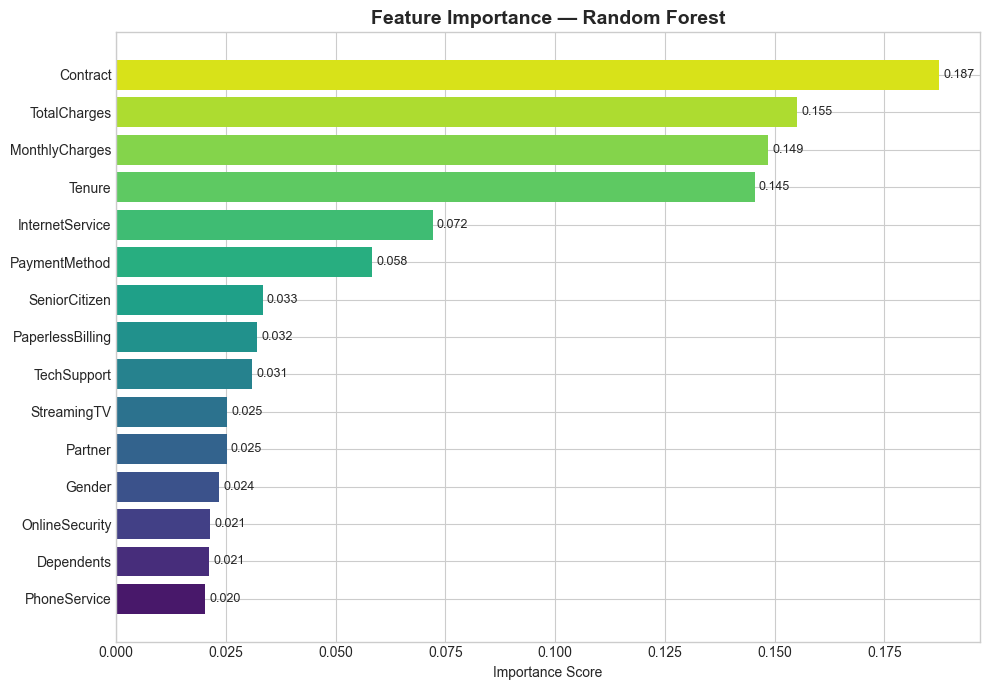

In [15]:
# --- Feature Importance (Random Forest) ---
rf_model    = models['Random Forest']
feat_imp    = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color=sns.color_palette('viridis', len(feat_imp)))
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 📋 8. Classification Report

In [16]:
for name, res in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['No Churn', 'Churned']))
    print(f'  CV Accuracy: {res["CV_Mean"]*100:.2f}% ± {res["CV_Std"]*100:.2f}%')


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.76      0.94      0.84       287
     Churned       0.61      0.25      0.35       113

    accuracy                           0.74       400
   macro avg       0.68      0.59      0.60       400
weighted avg       0.72      0.74      0.70       400

  CV Accuracy: 73.19% ± 0.82%

  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.75      0.90      0.82       287
     Churned       0.48      0.24      0.32       113

    accuracy                           0.71       400
   macro avg       0.62      0.57      0.57       400
weighted avg       0.67      0.71      0.68       400

  CV Accuracy: 68.94% ± 1.20%

  Random Forest
              precision    recall  f1-score   support

    No Churn       0.75      0.97      0.84       287
     Churned       0.69      0.16      0.26       113

    accuracy                           0.74       400
   macro av

## 🔮 9. Live Churn Prediction Demo

In [17]:
def predict_churn(gender, senior, partner, dependents, tenure,
                  phone, internet, security, tech, streaming,
                  contract, paperless, payment, monthly, total):
    """
    Predict if a customer will churn using Random Forest.
    """
    gender_map   = {'Male': 1, 'Female': 0}
    yn_map       = {'Yes': 1, 'No': 0}
    internet_map = {'DSL': 0, 'Fiber optic': 1, 'No': 2}
    contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    payment_map  = {'Bank transfer': 0, 'Credit card': 1,
                    'Electronic check': 2, 'Mailed check': 3}

    features = np.array([[
        gender_map[gender], senior, yn_map[partner], yn_map[dependents],
        tenure, yn_map[phone], internet_map[internet],
        yn_map[security], yn_map[tech], yn_map[streaming],
        contract_map[contract], yn_map[paperless],
        payment_map[payment], monthly, total
    ]])

    features_scaled = scaler.transform(features)
    rf = models['Random Forest']
    pred      = rf.predict(features_scaled)[0]
    prob      = rf.predict_proba(features_scaled)[0][1]

    print(f'\n👤 Customer Profile:')
    print(f'   Contract: {contract} | Tenure: {tenure} months | Monthly: ${monthly}')
    print(f'   Internet: {internet} | Security: {security} | Tech Support: {tech}')
    print(f'   Payment: {payment}')
    print(f'\n🔮 Churn Prediction: {"⚠️  WILL CHURN" if pred == 1 else "✅  WILL STAY"}')
    print(f'   Churn Probability: {prob*100:.1f}%')
    return pred, prob

# Test 1 — High risk customer
predict_churn('Male', 0, 'No', 'No', 3,
              'Yes', 'Fiber optic', 'No', 'No', 'Yes',
              'Month-to-month', 'Yes', 'Electronic check', 95.5, 286.5)

print('\n' + '='*50)

# Test 2 — Low risk customer
predict_churn('Female', 0, 'Yes', 'Yes', 48,
              'Yes', 'DSL', 'Yes', 'Yes', 'No',
              'Two year', 'No', 'Credit card', 55.0, 2640.0)


👤 Customer Profile:
   Contract: Month-to-month | Tenure: 3 months | Monthly: $95.5
   Internet: Fiber optic | Security: No | Tech Support: No
   Payment: Electronic check

🔮 Churn Prediction: ⚠️  WILL CHURN
   Churn Probability: 56.8%


👤 Customer Profile:
   Contract: Two year | Tenure: 48 months | Monthly: $55.0
   Internet: DSL | Security: Yes | Tech Support: Yes
   Payment: Credit card

🔮 Churn Prediction: ✅  WILL STAY
   Churn Probability: 4.6%


(np.int64(0), np.float64(0.046112640348626624))

## 📝 10. Final Summary

In [18]:
best_model = max(results, key=lambda m: results[m]['F1'])

print('=' * 60)
print('     CUSTOMER CHURN PREDICTION — FINAL SUMMARY')
print('=' * 60)
print(f'\n📊 Dataset: 2000 customers | {df["Churn"].mean()*100:.1f}% churn rate')
print(f'\n🏆 Best Model: {best_model}')
print(f'   Accuracy  : {results[best_model]["Accuracy"]*100:.2f}%')
print(f'   F1 Score  : {results[best_model]["F1"]:.4f}')
print(f'   ROC-AUC   : {results[best_model]["ROC_AUC"]:.4f}')

print('\n📌 Model Comparison:')
for name, res in results.items():
    print(f'   {name:<25} Acc: {res["Accuracy"]*100:.1f}% | F1: {res["F1"]:.4f} | AUC: {res["ROC_AUC"]:.4f}')

print('\n📊 Key Churn Drivers (from EDA):')
print('   • Month-to-month contract → highest churn risk')
print('   • Fiber optic internet → higher churn than DSL')
print('   • Electronic check payment → more likely to churn')
print('   • Low tenure (< 12 months) → very high churn risk')
print('   • No tech support / security → increases churn')
print('\n✅ Models: Logistic Regression | Decision Tree | Random Forest')
print('✅ Metrics: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix')
print('=' * 60)

     CUSTOMER CHURN PREDICTION — FINAL SUMMARY

📊 Dataset: 2000 customers | 28.3% churn rate

🏆 Best Model: Logistic Regression
   Accuracy  : 74.25%
   F1 Score  : 0.3522
   ROC-AUC   : 0.7365

📌 Model Comparison:
   Logistic Regression       Acc: 74.2% | F1: 0.3522 | AUC: 0.7365
   Decision Tree             Acc: 71.2% | F1: 0.3195 | AUC: 0.7046
   Random Forest             Acc: 74.2% | F1: 0.2590 | AUC: 0.7381

📊 Key Churn Drivers (from EDA):
   • Month-to-month contract → highest churn risk
   • Fiber optic internet → higher churn than DSL
   • Electronic check payment → more likely to churn
   • Low tenure (< 12 months) → very high churn risk
   • No tech support / security → increases churn

✅ Models: Logistic Regression | Decision Tree | Random Forest
✅ Metrics: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix
